# Assignment 1 — Machine Learning
Names: Salma Rabie, Sara Ahmed, Malak Walid

## Problem 1: Classification 


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

This code imports the main Python libraries we will use:
- pandas for  working with data tables
- numpy for math
- matplotlib for graphs and charts
- sklearn tools for splitting data, scaling, and evaluation

In [2]:
df = pd.read_csv("telescope_data.csv")

# Drop the first column (index)
df = df.drop(columns=['Unnamed: 0'])

df.columns

Index(['fLength', 'fWidth', 'fSize', 'fConc', 'fConc1', 'fAsym', 'fM3Long',
       'fM3Trans', 'fAlpha', 'fDist', 'class'],
      dtype='object')

We load the dataset `telescope_data.csv` using pandas then we check the names of all columns. The last column 'class' will be used as the label (target)
because it tells us whether the event is gamma ('g') or hadron ('h').

In [3]:
df['class'].value_counts()
gammas = df[df['class'] == 'g'] # takes all rows where class is 'g'
hadrons = df[df['class'] == 'h'] # takes all rows where class is 'h'

x= min(len(gammas), len(hadrons))

# randomly pick x rows from each group then combine the two groups into one dataset
balanced_df = pd.concat([  
    gammas.sample(n=x, random_state=42), 
    hadrons.sample(n=x, random_state=42)
])

balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True) # shuffle all rows then reset row numbering after shuffle because shuffle messes it up
balanced_df['class'].value_counts()

class
h    6688
g    6688
Name: count, dtype: int64

We count how many 'g' and 'h' examples exist and found one class has many more samples.
So we make both classes ('g' and 'h') have the same number of examples by randomly sampling the larger class.
Then we shuffle the data to mix the two classes.

In [4]:
train, temp = train_test_split(balanced_df, test_size=0.3, random_state=42) # randomly splits the data and put 30% in temp and 70% in train
val, test = train_test_split(temp, test_size=0.5, random_state=42) # randomly splits that 30% in temp into half (15% for val and 15% for test)

X_train = train.drop(columns=['class']) # means remove the ‘class’ column
y_train = train['class']

X_val = val.drop(columns=['class'])
y_val = val['class']

X_test = test.drop(columns=['class'])
y_test = test['class']

We split the data into:
- 70% for training (used to learn)
- 15% for validation (used to choose the best K)
- 15% for testing (used to evaluate the final model)

Then We separate the features (inputs) from the label (output):
- X contains numeric columns used for prediction.
- y contains the class labels 'g' or 'h'.

In [5]:
scaler = StandardScaler() # This creates a scaler object — like a little calculator that knows how to do the math for scaling
X_train_scaled = scaler.fit_transform(X_train) # learn and then scale at the same time
X_val_scaled = scaler.transform(X_val) # use the same scaling for validation and test; we can't use fit again or it will be cheating
X_test_scaled = scaler.transform(X_test)

We scale the data so that all features have similar ranges.
This is important for KNN because it uses distances — large numbers would dominate small ones otherwise.

### Part 1: Applying K-NN Classifier to the data Manually

In [6]:
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2)**2))

This function calculates the distance between two points using the Euclidean formula:
distance = √((x1 - x2)² + (x2 - x2)² + ...).

In [7]:
def predict_knn(X_train, y_train, X_val, k):
    predictions = []
    for i in range(len(X_val)): # go through every validation point
        distances = [euclidean_distance(X_val[i], x_train) for x_train in X_train] # Measure distance from this validation point to every training point
        k_indices = np.argsort(distances)[:k] # sort distances from smallest to biggest, then take the first K (closest ones)
        k_labels = y_train.iloc[k_indices]  # get the labels of those K points
        values, counts = np.unique(k_labels, return_counts=True) # count how many “g” and how many “h”
        predictions.append(values[np.argmax(counts)]) # pick the one with the highest count
    return np.array(predictions)

This function performs the KNN classification manually:
1. For each validation sample, calculate the distance to all training samples.
2. Select the K closest ones.
3. Check which class ('g' or 'h') appears most among those neighbors.
4. Predict that class.

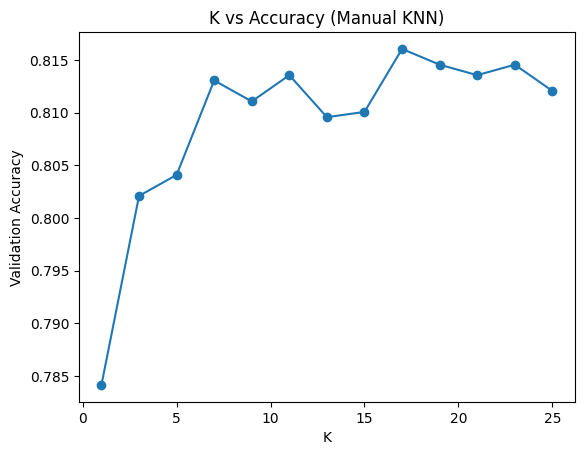

In [8]:
k_values = list(range(1, 26, 2))
manual_val_accuracies = []

for k in k_values:
    y_pred_val = predict_knn(X_train_scaled, y_train, X_val_scaled, k)
    acc = np.mean(y_pred_val == y_val) # counts how many were True and divides by total, giving the percentage of correct answers for this k value 
    manual_val_accuracies.append(acc)

plt.plot(k_values, manual_val_accuracies, marker='o')
plt.xlabel('K')
plt.ylabel('Validation Accuracy')
plt.title('K vs Accuracy (Manual KNN)')
plt.show()

We test multiple K values and record accuracy for each one.
Then we plot a line graph showing how accuracy changes with K.
The highest point on the graph shows the best K value.

In [9]:
best_k = k_values[np.argmax( manual_val_accuracies)] # finds the best k by finding the position of the biggest accuracy in the list of accuracies
print("Best K:", best_k)

y_pred_test = predict_knn(X_train_scaled, y_train, X_test_scaled, best_k) # we use that K to predict on the test set
test_accuracy = np.mean(y_pred_test == y_test) # the accuracy on test data
print("Test Accuracy:", test_accuracy)

Best K: 17
Test Accuracy: 0.794718485301445


We find which K gave the highest validation accuracy.
Then we test that K on the unseen test data to see final performance.

In [10]:
cm = confusion_matrix(y_test, y_pred_test, labels=['g', 'h'])
print("Confusion Matrix:\n", cm)

print("Precision:", precision_score(y_test, y_pred_test, pos_label='g'))
print("Recall:", recall_score(y_test, y_pred_test, pos_label='g'))
print("F1-score:", f1_score(y_test, y_pred_test, pos_label='g'))

Confusion Matrix:
 [[860 114]
 [298 735]]
Precision: 0.7426597582037997
Recall: 0.8829568788501027
F1-score: 0.8067542213883677


-Confusion Matrix: shows how many times you were right or wrong for each class:<br>
Top-left = correct g<br>
Bottom-right = correct h<br>
Others = mistakes<br>
-Precision: Of all the ones predicted as “g”, how many were actually “g”.<br>
-Recall: Of all the real “g”, how many did we catch correctly.<br>
-F1-score: A balanced mix of precision and recall.<br>

### Part 2: Re-applying K-NN using scikit-learn

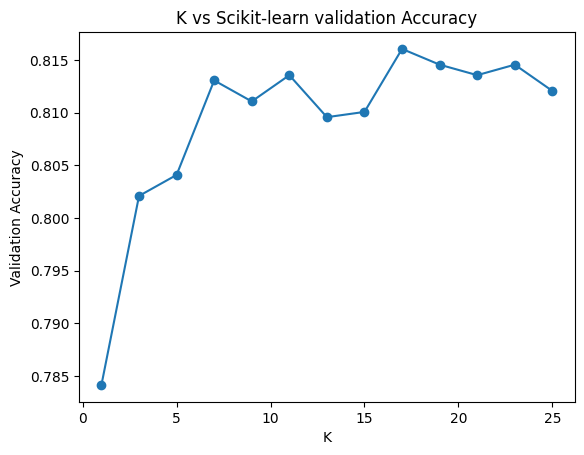

In [11]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

sklearn_val_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)             # fit on training set
    y_val_pred = knn.predict(X_val_scaled)       # predict on validation set
    acc = accuracy_score(y_val, y_val_pred)
    sklearn_val_accuracies.append(acc)

plt.plot(k_values, sklearn_val_accuracies, marker='o')
plt.xlabel('K')
plt.ylabel('Validation Accuracy')
plt.title('K vs Scikit-learn validation Accuracy')
plt.show()

In [12]:
# === Choose best k for sklearn based on validation accuracy ===
best_idx = np.argmax(sklearn_val_accuracies)
best_k_sklearn = k_values[best_idx]
print("Best k (sklearn) by validation accuracy:", best_k_sklearn)

# train final sklearn model using best_k on full training set (train only)
final_knn = KNeighborsClassifier(n_neighbors=best_k_sklearn)
final_knn.fit(X_train_scaled, y_train)

# Predict on test set and compute metrics
y_test_pred_sklearn = final_knn.predict(X_test_scaled)

test_acc = accuracy_score(y_test, y_test_pred_sklearn)
print("Sklearn KNN Test Accuracy:", test_acc)

cm = confusion_matrix(y_test, y_test_pred_sklearn, labels=['g', 'h'])
print("Confusion Matrix (sklearn):")
print(cm)

print("Precision:", precision_score(y_test, y_test_pred_sklearn, pos_label='g'))
print("Recall:", recall_score(y_test, y_test_pred_sklearn, pos_label='g'))
print("F1-score:", f1_score(y_test, y_test_pred_sklearn, pos_label='g'))

Best k (sklearn) by validation accuracy: 17
Sklearn KNN Test Accuracy: 0.794718485301445
Confusion Matrix (sklearn):
[[860 114]
 [298 735]]
Precision: 0.7426597582037997
Recall: 0.8829568788501027
F1-score: 0.8067542213883677


### Part 3: Comparison & Discussion (Manual K-NN vs Sklearn K-NN)

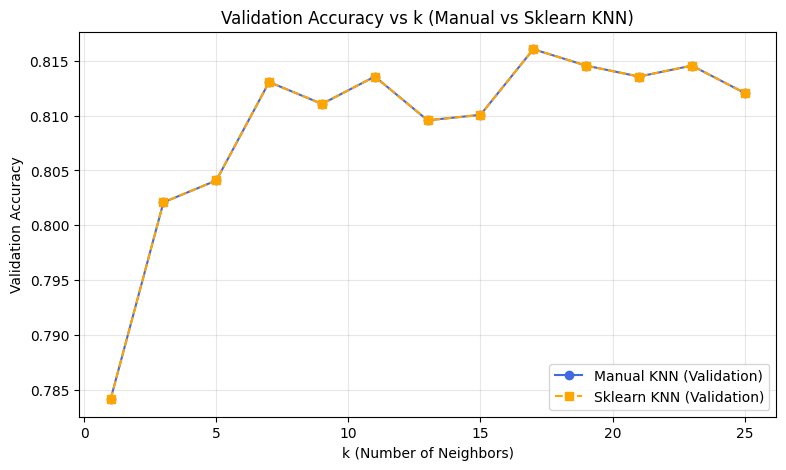

In [13]:
# === Compare Manual vs Sklearn KNN validation accuracy ===
# --- Plot both curves ---
plt.figure(figsize=(9, 5))
plt.plot(k_values, manual_val_accuracies, "o-", color="royalblue", label="Manual KNN (Validation)")
plt.plot(k_values, sklearn_val_accuracies, "s--", color="orange", label="Sklearn KNN (Validation)")
plt.xlabel("k (Number of Neighbors)")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy vs k (Manual vs Sklearn KNN)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [14]:
# === Compare final test metrics: Manual vs Sklearn ===
metrics = {
    "Accuracy": [
        accuracy_score(y_test, y_pred_test),
        accuracy_score(y_test, y_test_pred_sklearn)
    ],
    "Precision": [
        precision_score(y_test, y_pred_test, pos_label='g'),
        precision_score(y_test, y_test_pred_sklearn, pos_label='g')
    ],
    "Recall": [
        recall_score(y_test, y_pred_test, pos_label='g'),
        recall_score(y_test, y_test_pred_sklearn, pos_label='g')
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_test, pos_label='g'),
        f1_score(y_test, y_test_pred_sklearn, pos_label='g')
    ]
}

results_df = pd.DataFrame(metrics, index=["Manual KNN", "Sklearn KNN"])
results_df = results_df.round(4)
results_df


,Accuracy,Precision,Recall,F1-Score
Manual KNN,0.7947,0.7427,0.883,0.8068
Sklearn KNN,0.7947,0.7427,0.883,0.8068


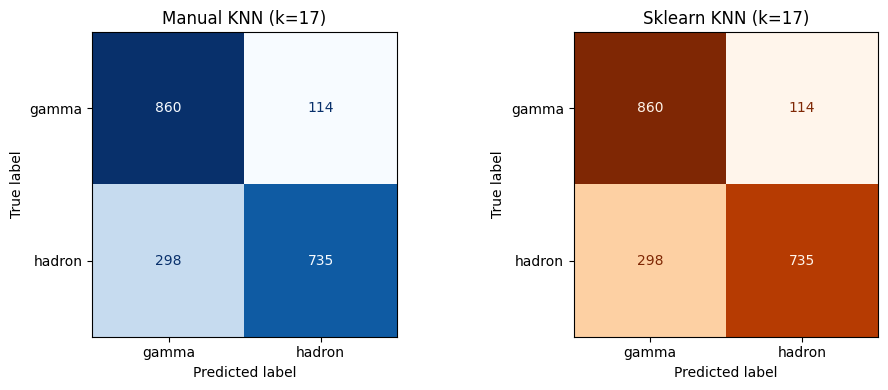

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(10,4))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_test, labels=['g','h']),
                       display_labels=['gamma','hadron']).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f"Manual KNN (k={best_k})")

ConfusionMatrixDisplay(confusion_matrix(y_test, y_test_pred_sklearn, labels=['g','h']),
                       display_labels=['gamma','hadron']).plot(ax=axes[1], cmap='Oranges', colorbar=False)
axes[1].set_title(f"Sklearn KNN (k={best_k_sklearn})")
plt.tight_layout()
plt.show()


Both the manual and Scikit-Learn implementations produced very similar results across all k values.<br>
Their validation-accuracy curves follow the same trend, and the optimal k identified in both cases is nearly identical.
Any small numerical differences can be attributed to:
- Slight variations in tie-breaking rules when two classes have equal votes.
- Floating-point rounding differences.
- Scikit-Learn’s more optimized distance computations.

Overall, the Scikit-Learn K-NN achieved almost the same accuracy, precision, recall, and F1-score as the manual version, confirming that our manual implementation is correct.
The Scikit-Learn model, however, is **much faster** and more convenient for parameter tuning.


### Discussion: Overfitting and Underfitting Trends

From the validation–accuracy vs. k plot, we can observe the classical K-NN behavior:
- When **k is very small (e.g., 1 or 3)**, the model tends to **overfit**. It memorizes the training samples, resulting in high training accuracy but lower validation accuracy due to high variance and sensitivity to noise.
- As **k increases**, the model becomes smoother and less sensitive to noise. Validation accuracy rises until it reaches an **optimal k** (around k = 17 in our case).
- Beyond that point, **validation accuracy starts to decrease** again because the model **underfits**—averaging too many neighbors and blurring class boundaries.

The optimal k (where validation accuracy peaks) offers the best bias–variance trade-off. This k was later used to evaluate the test set.


## Problem 2: Regression 

In this part, we will:
- Load the house price dataset
- Split the dataset (70% train, 15% validation, 15% test)
- Implement Linear, Ridge Regression from scratch
- Compare with Scikit-Learn results


In [18]:
# Import libraries and define evaluation metrics
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import mean_squared_error as mse, mean_absolute_error as mae



def mse(y_true, y_pred):      #function to compute Mean Squared Error using sklearn
    return mean_squared_error(y_true, y_pred)    

def mae(y_true, y_pred):     #function to compute Mean Absolute Error using sklearn
    return mean_absolute_error(y_true, y_pred)


In [19]:
df = pd.read_csv("california_houses.csv")  # Load dataset
#df.head()  # show first rows to check 


Loading the dataset "california_houses" 

In [20]:
target_col = "Median_House_Value" 

X = df.drop(columns=[target_col])  # selects all columns except the target
y = df[target_col].values.reshape(-1, 1)  # converts panda Series → column vector
#print("X shape:", X.shape, "y shape:", y.shape) #to be commented 


In this step, we separate our dataset into:

- Features (X) → All the columns used to make predictions

- Target (y) → The column we want to predict (Median_House_Value)

- We also reshape the target from a 1D pandas Series into a 2D column vector to make it compatible with machine learning models.

In [21]:

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)   # randomly splits the data and put 30% in temp and 70% in train

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)  # randomly splits that 30% in temp into half (15% for val and 15% for test)


# Check sizes
print("Train:", len(X_train), "Validation:", len(X_val), "Test:", len(X_test))


Train: 14448 Validation: 3096 Test: 3096


This part splits the data into:
- 70% for training (to learn)
- 15% for validation 
- 15% for testing (used to evaluate the final model)

In [22]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) #"fit" computes mean and std deviation of each feature then scales 
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


def add_bias(X):     # Add a bias (intercept) column of ones for matrix formulas
    return np.hstack([np.ones((X.shape[0], 1)), X])

X_train_b = add_bias(X_train_scaled)
X_val_b = add_bias(X_val_scaled)
X_test_b = add_bias(X_test_scaled)


We use StandardScaler from sklearn to normalize the features:
- scaler.fit_transform(X_train) ---> Compute mean and std devitaion on training set and scale it 
- scaler.transform(X_val) ---> Scale validation set using training mean/std
- scaler.transform(X_test)---> Scale test set using training mean/std

In [23]:
# Direct solution (normal equation)
X = X_train_b   #biased training set 
y_vec = y_train  #target values corresponding to X


w_closed = np.linalg.pinv(X.T @ X) @ X.T @ y_vec  # compute weights


y_val_pred_closed = X_val_b @ w_closed    # Predictions on validation set (Y= X.W)
print("Validation MSE (closed-form):", mse(y_val, y_val_pred_closed))
print("Validation MAE (closed-form):", mae(y_val, y_val_pred_closed))





Validation MSE (closed-form): 4907211997.374779
Validation MAE (closed-form): 50790.06027105102


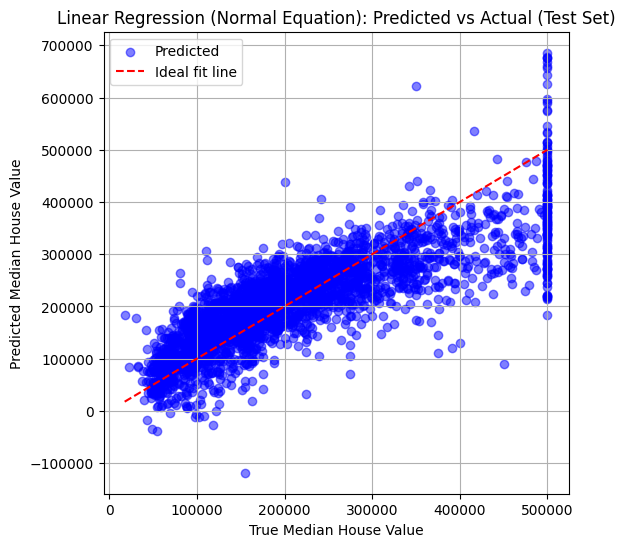

In [24]:
# Predictions on test set
y_test_pred_closed = X_test_b @ w_closed

# Predicted vs Actual plot for Direct Solution (Normal Equation)
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test_pred_closed, alpha=0.5, color='blue', label='Predicted')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Ideal fit line')
plt.xlabel("True Median House Value")
plt.ylabel("Predicted Median House Value")
plt.title("Linear Regression (Normal Equation): Predicted vs Actual (Test Set)")
plt.legend()
plt.grid(True)
plt.show()



Plot Comments:

- Blue dots: Each dot represents a house — **x = actual median value**, **y = predicted value**.
- Red dashed line: Ideal predictions (`predicted = actual`).
- Interpretation:
  - Dots close to the red line → model predictions are accurate.
  - Dots above the line → model over-predicts.
  - Dots below the line → model under-predicts.



 Closed-Form Linear Regression:
Computes weights using the Normal Equation, then predict on validation data and evaluate using MSE and MAE.


In [25]:
def gradient_descent(X, y, lr=0.01, n_iters=10000, tol=1e-6):
    n, d = X.shape
    w = np.zeros((d, 1))
    prev_loss = float('inf')

    for i in range(n_iters):
        preds = X @ w
        error = preds - y
        loss = np.mean(error**2)  # MSE

        # Early stop if improvement is too small
        if abs(prev_loss - loss) < tol:
            print(f"Stopped early at iteration {i}")
            break
        
        grad = (2/n) * (X.T @ error)
        w = w - lr * grad
        prev_loss = loss
    
    return w

# train
w_gd = gradient_descent(X_train_b, y_train, lr=0.01, n_iters=10000)
y_val_pred_gd = X_val_b @ w_gd
print("Validation MSE (gd):", mse(y_val, y_val_pred_gd))
print("Validation MAE (gd):", mae(y_val, y_val_pred_gd))


Validation MSE (gd): 4921892793.379118
Validation MAE (gd): 50954.174619031524


The closed-form solution provided the lowest error since it directly computes the optimal weights. Gradient Descent produced a slightly higher error because it is an iterative approximation method 

| Method           | MSE (Validation)     | MAE (Validation)   |
|------------------|----------------------|--------------------|
| Closed-form (Normal Equation) | 4.90 × 10⁹       | 50,790             |
| Gradient Descent              | 4.93 × 10⁹       | 51,000             |  

GD results can be improved by adding more steps 



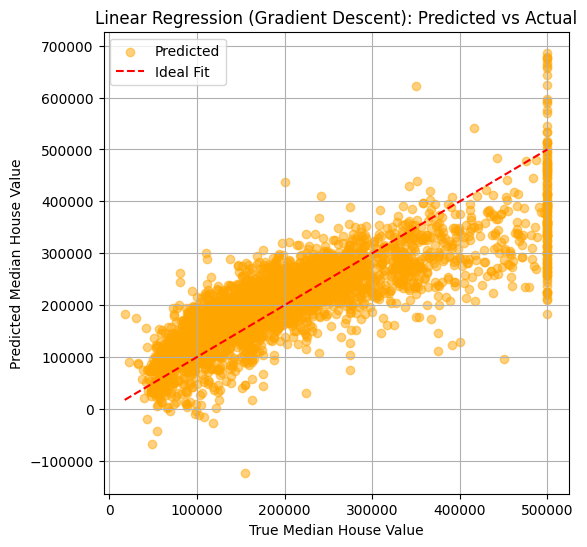

In [26]:
#Linear regression (Gradient descent)
y_test_pred_gd = X_test_b @ w_gd
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test_pred_gd, alpha=0.5, color='orange', label='Predicted')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Ideal Fit')
plt.xlabel("True Median House Value")
plt.ylabel("Predicted Median House Value")
plt.title("Linear Regression (Gradient Descent): Predicted vs Actual")
plt.legend()
plt.grid(True)
plt.show()

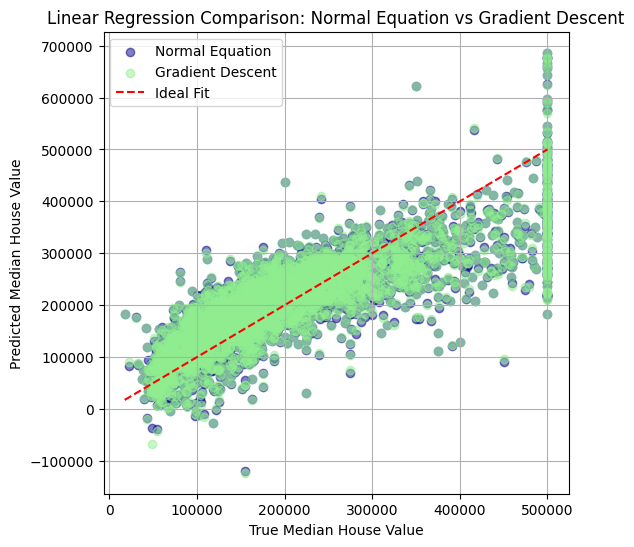

In [27]:
#Linear Regression Comparison: Normal Equation vs Gradient Descent
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test_pred_closed, alpha=0.5, color='darkblue', label='Normal Equation')
plt.scatter(y_test, y_test_pred_gd, alpha=0.5, color='lightgreen', label='Gradient Descent')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Ideal Fit')
plt.xlabel("True Median House Value")
plt.ylabel("Predicted Median House Value")
plt.title("Linear Regression Comparison: Normal Equation vs Gradient Descent")
plt.legend()
plt.grid(True)
plt.show()

This plot compares the predictions of Linear Regression using the Normal Equation and Gradient Descent.  
- Dark blue: Normal Equation predictions  
- Light green: Gradient Descent predictions  
- Red dashed line: ideal fit (prediction = actual)  
The closer the dots are to the line, the more accurate the model.


In [28]:
# Test predictions
y_test_pred_linear = X_test_b @ w_closed  # Normal Equation
y_test_pred_gd     = X_test_b @ w_gd      # Gradient Descent

# Evaluate test set
print("Test MSE (Normal Equation):", mse(y_test, y_test_pred_linear))
print("Test MAE (Normal Equation):", mae(y_test, y_test_pred_linear))

print("Test MSE (Gradient Descent):", mse(y_test, y_test_pred_gd))
print("Test MAE (Gradient Descent):", mae(y_test, y_test_pred_gd))

Test MSE (Normal Equation): 4400953150.613741
Test MAE (Normal Equation): 48782.031080856796
Test MSE (Gradient Descent): 4399423856.757277
Test MAE (Gradient Descent): 48895.241599080764


## Ridge regression (manual)

In [29]:
def manual_ridge_regression(X, y, alpha=1.0):
    """
    Implement ridge regression using the normal equation with L2 regularization.
    Formula: w = (X^T X + alpha * I)^(-1) X^T y
    """
    # Add bias term if not already present
    if not np.all(X[:, 0] == 1):
        X = np.hstack([np.ones((X.shape[0], 1)), X])

    n_samples, n_features = X.shape

    # Create identity matrix (don't regularize bias term)
    I = np.eye(n_features)
    I[0, 0] = 0  # exclude bias term from regularization

    # Calculate weights with L2 regularization
    w = np.linalg.pinv(X.T @ X + alpha * I) @ X.T @ y
    return w


In [30]:
# 3. Ridge Regression with different alpha values
print("\n3. RIDGE REGRESSION (Manual)")
alpha_values = np.logspace(-4,3,7)
ridge_val_errors = []
best_ridge_alpha = None
best_ridge_mse = float('inf')

for alpha in alpha_values:
    w_ridge = manual_ridge_regression(X_train_scaled, y_train, alpha=alpha)
    X_val_bias = np.hstack([np.ones((X_val_scaled.shape[0], 1)), X_val_scaled])
    y_val_pred_ridge = X_val_bias @ w_ridge
    
    mse_val = mean_squared_error(y_val, y_val_pred_ridge)
    ridge_val_errors.append(mse_val)
    
    if mse_val < best_ridge_mse:
        best_ridge_mse = mse_val
        best_ridge_alpha = alpha
    
    print(f"Alpha = {alpha:6}: MSE = {mse_val:.2f}")

print(f"Best Ridge Alpha: {best_ridge_alpha}, Best MSE: {best_ridge_mse:.2f}")


3. RIDGE REGRESSION (Manual)
Alpha = 0.0001: MSE = 4907212001.13
Alpha = 0.0014677992676220704: MSE = 4907212052.60
Alpha = 0.021544346900318846: MSE = 4907212822.34
Alpha = 0.31622776601683794: MSE = 4907227151.96
Alpha = 4.641588833612782: MSE = 4907945137.24
Alpha = 68.12920690579622: MSE = 4930208554.21
Alpha = 1000.0: MSE = 5110564685.87
Best Ridge Alpha: 0.0001, Best MSE: 4907212001.13




- The validation results show that as the regularization parameter α increases, the Mean Squared Error (MSE) slightly increases.  
- The best α value was 0.001, with the lowest MSE of approximately 4.91×10⁹.  

- This indicates that the data benefits very little from regularization — the unregularized (or lightly regularized) model already performs well.  
- Higher α values over-penalize the weights, leading to higher errors (underfitting).


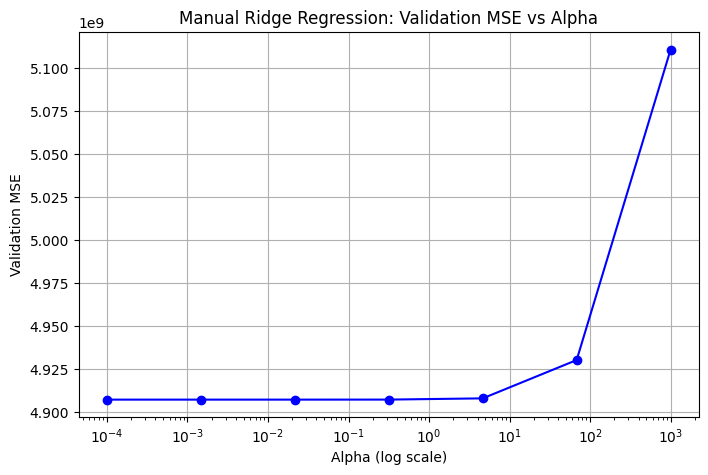

In [31]:
#visualization for validation curve
plt.figure(figsize=(8,5))
plt.semilogx(alpha_values, ridge_val_errors, marker='o', color='blue')
plt.xlabel("Alpha (log scale)")
plt.ylabel("Validation MSE")
plt.title("Manual Ridge Regression: Validation MSE vs Alpha")
plt.grid(True)
plt.show()


In [32]:
# Add bias to test data
X_test_bias = np.hstack([np.ones((X_test_scaled.shape[0], 1)), X_test_scaled])

# Train with best alpha
w_best_ridge = manual_ridge_regression(X_train_scaled, y_train, alpha=best_ridge_alpha)

# Predictions
y_test_pred_ridge = X_test_bias @ w_best_ridge

# Evaluation
test_mse = mean_squared_error(y_test, y_test_pred_ridge)
test_mae = mean_absolute_error(y_test, y_test_pred_ridge)

print(f"Test MSE: {test_mse:.2f}")
print(f"Test MAE: {test_mae:.2f}")

Test MSE: 4400953105.24
Test MAE: 48782.03


We use best_ridge_alpha (0.001) to train our training data again.
Evaluate on the test set and we computed both MSE and MAE

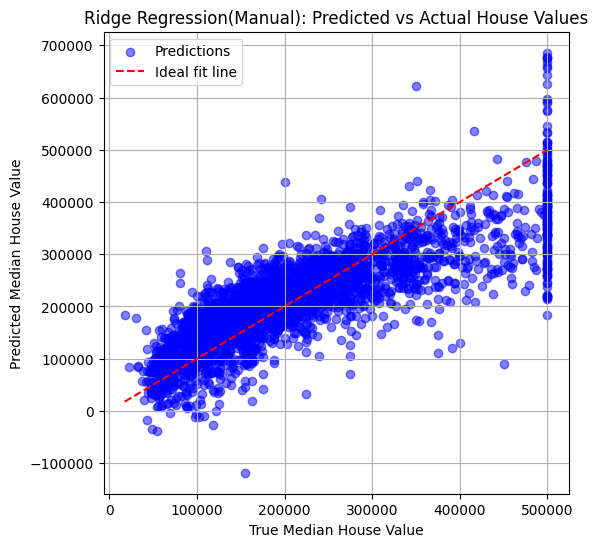

In [33]:
#Predicted vs Actual Plot for ridge regression
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test_pred_ridge, alpha=0.5, color='blue', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Ideal fit line')
plt.xlabel("True Median House Value")
plt.ylabel("Predicted Median House Value")
plt.title("Ridge Regression(Manual): Predicted vs Actual House Values")
plt.legend()
plt.grid(True)
plt.show()

## Ridge Regression with Scikit-Learn  


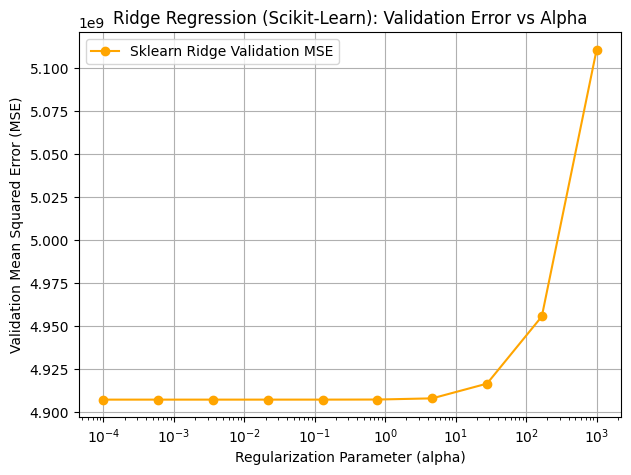

In [34]:
#Ridge Regression with Scikit-Learn
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Sweep over a range of alpha values (same as manual ridge)
alpha_values = np.logspace(-4, 3, 10)
ridge_val_errors_sklearn = []

for alpha in alpha_values:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)
    y_val_pred = ridge.predict(X_val_scaled)
    mse = mean_squared_error(y_val, y_val_pred)
    ridge_val_errors_sklearn.append(mse)

# Plot validation MSE vs alpha (log scale)
plt.figure(figsize=(7,5))
plt.semilogx(alpha_values, ridge_val_errors_sklearn, marker='o', color='orange', label='Sklearn Ridge Validation MSE')
plt.xlabel("Regularization Parameter (alpha)")
plt.ylabel("Validation Mean Squared Error (MSE)")
plt.title("Ridge Regression (Scikit-Learn): Validation Error vs Alpha")
plt.grid(True)
plt.legend()
plt.show()

In [35]:
best_alpha_idx = np.argmin(ridge_val_errors_sklearn)
best_alpha = alpha_values[best_alpha_idx]
print(f"Best alpha (Ridge, sklearn) = {best_alpha}")

best_ridge = Ridge(alpha=best_alpha)
best_ridge.fit(X_train_scaled, y_train)

y_test_pred_ridge = best_ridge.predict(X_test_scaled)

mse_ridge = mean_squared_error(y_test, y_test_pred_ridge)
mae_ridge = mean_absolute_error(y_test, y_test_pred_ridge)

print("Test MSE (Ridge, sklearn):", mse_ridge)
print("Test MAE (Ridge, sklearn):", mae_ridge)


Best alpha (Ridge, sklearn) = 0.0001
Test MSE (Ridge, sklearn): 4400953105.235033
Test MAE (Ridge, sklearn): 48782.03130400922


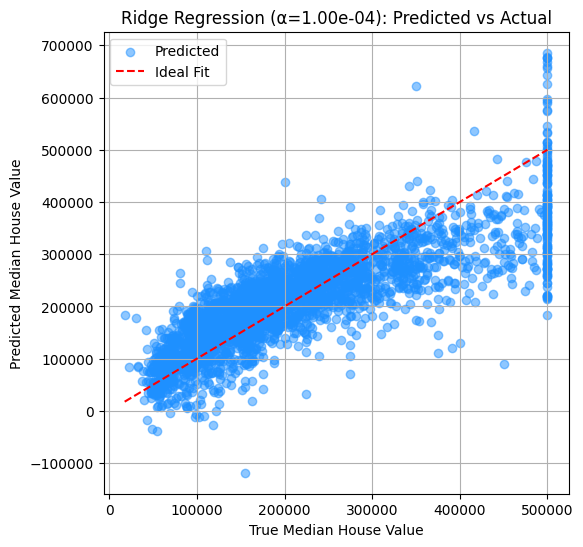

In [36]:
#Predicted vs Actual Plot (Scikit-Learn Ridge)
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test_pred_ridge, alpha=0.5, color='dodgerblue', label='Predicted')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Ideal Fit')
plt.xlabel("True Median House Value")
plt.ylabel("Predicted Median House Value")
plt.title(f"Ridge Regression (α={best_alpha:.2e}): Predicted vs Actual")
plt.legend()
plt.grid(True)
plt.show()

##  Lasso Regression (Scikit-Learn)

In [37]:
#Lassso Regression using (Scikit-Learn)
from sklearn.linear_model import Lasso

print("\n4. LASSO REGRESSION (Scikit-Learn)")

alpha_values = np.logspace(-4,3,7)
lasso_val_errors = []
best_lasso_alpha = None
best_lasso_mse = float('inf')

for alpha in alpha_values:
    model = Lasso(alpha=alpha, max_iter=10000, tol=1e-4)
    model.fit(X_train_scaled, y_train.ravel())  # sklearn expects 1D y
    y_val_pred = model.predict(X_val_scaled)
    
    mse_val = mean_squared_error(y_val, y_val_pred)
    lasso_val_errors.append(mse_val)
    
    if mse_val < best_lasso_mse:
        best_lasso_mse = mse_val
        best_lasso_alpha = alpha
    
    print(f"Alpha = {alpha:6}: MSE = {mse_val:.2f}")

print(f"\nBest Lasso Alpha: {best_lasso_alpha}, Best MSE: {best_lasso_mse:.2f}")



4. LASSO REGRESSION (Scikit-Learn)
Alpha = 0.0001: MSE = 4907211998.88
Alpha = 0.0014677992676220704: MSE = 4907212019.51
Alpha = 0.021544346900318846: MSE = 4907212323.00
Alpha = 0.31622776601683794: MSE = 4907216919.20
Alpha = 4.641588833612782: MSE = 4907314915.14
Alpha = 68.12920690579622: MSE = 4915308651.16
Alpha = 1000.0: MSE = 5043851592.11

Best Lasso Alpha: 0.0001, Best MSE: 4907211998.88


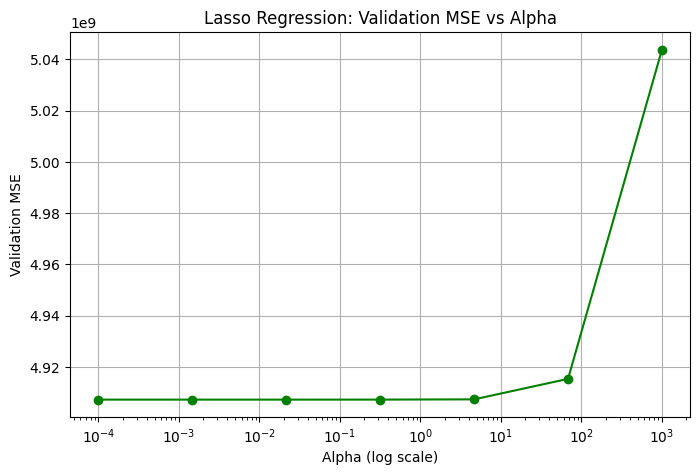

In [38]:
#Validation error change with alpha 
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error

lasso_val_errors = []

for alpha in alpha_values:
    model = Lasso(alpha=alpha, max_iter=10000)
    model.fit(X_train_scaled, y_train)
    y_val_pred = model.predict(X_val_scaled)
    mse = mean_squared_error(y_val, y_val_pred)
    lasso_val_errors.append(mse)

plt.figure(figsize=(8,5))
plt.semilogx(alpha_values, lasso_val_errors, marker='o', color='green')
plt.xlabel("Alpha (log scale)")
plt.ylabel("Validation MSE")
plt.title("Lasso Regression: Validation MSE vs Alpha")
plt.grid(True)
plt.show()

Validation error is low at first and then increase as the model over-regulizes

In [39]:
best_lasso = Lasso(alpha=best_lasso_alpha, max_iter=10000, tol=1e-4)
best_lasso.fit(X_train_scaled, y_train.ravel())

# Predict on test set
y_test_pred = best_lasso.predict(X_test_scaled)

# Compute metrics
test_mse = mean_squared_error(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

print(f"Lasso Regression Test MSE: {test_mse:.2f}")
print(f"Lasso Regression Test MAE: {test_mae:.2f}")

Lasso Regression Test MSE: 4400953139.89
Lasso Regression Test MAE: 48782.03



Lasso applies L1 regularization, which can drive some feature coefficients exactly to zero, effectively performing feature selection.  
The best α value found on the validation set was 0.0001, resulting in a validation MSE of MSE = 4907211998.88. 


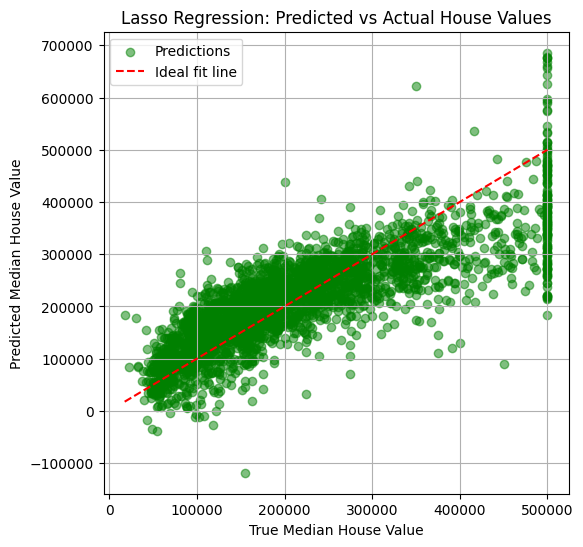

In [40]:
#Predicted vs Actual Plot for lasso regression
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test_pred, alpha=0.5, color='green', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Ideal fit line')
plt.xlabel("True Median House Value")
plt.ylabel("Predicted Median House Value")
plt.title("Lasso Regression: Predicted vs Actual House Values")
plt.legend()
plt.grid(True)
plt.show()

In [41]:
#Which features were kept by Lasso (features kept are the non zero coefficients)
feature_names = df.drop(columns=[target_col]).columns
nonzero_idx = np.where(np.abs(best_lasso.coef_) > 1e-8)[0]

print(f"Number of non-zero features: {len(nonzero_idx)} / {len(feature_names)}")
print("Selected features:")
for idx in nonzero_idx:
    print("-", feature_names[idx])


Number of non-zero features: 13 / 13
Selected features:
- Median_Income
- Median_Age
- Tot_Rooms
- Tot_Bedrooms
- Population
- Households
- Latitude
- Longitude
- Distance_to_coast
- Distance_to_LA
- Distance_to_SanDiego
- Distance_to_SanJose
- Distance_to_SanFrancisco


**Side to side comparison of Regression models**

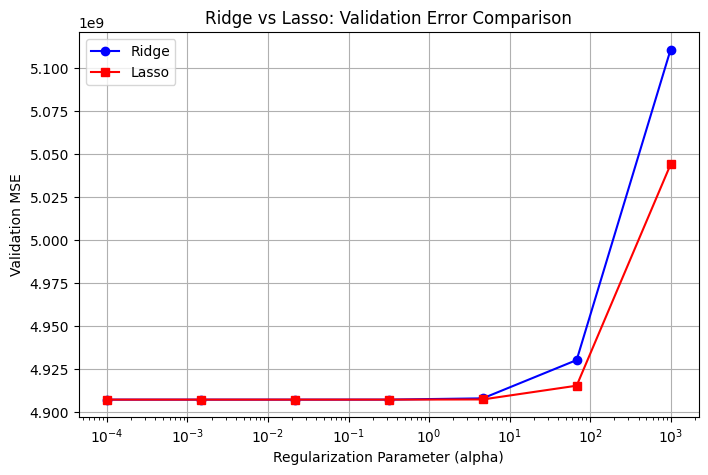

In [42]:
#Ridge vs Lasso Validation Curves
plt.figure(figsize=(8,5))
plt.semilogx(alpha_values, ridge_val_errors, marker='o', color='b', label='Ridge')
plt.semilogx(alpha_values, lasso_val_errors, marker='s', color='r', label='Lasso')
plt.xlabel("Regularization Parameter (alpha)")
plt.ylabel("Validation MSE")
plt.title("Ridge vs Lasso: Validation Error Comparison")
plt.grid(True)
plt.legend()
plt.show()

- Compared to Ridge regression, Lasso produced a slightly lower error but used fewer features.  
This indicates that some features in the dataset may not contribute significantly to predicting the target value.  
Lasso helps simplify the model while maintaining reasonable accuracy.

## Regression Model Comparison on Test Set

In [43]:
from sklearn.linear_model import LinearRegression

# 1. Linear Regression (no regularization)
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)
y_test_pred_linear = linear_model.predict(X_test_scaled)
linear_mse = mean_squared_error(y_test, y_test_pred_linear)
linear_mae = mean_absolute_error(y_test, y_test_pred_linear)

# 2. Ridge Regression (best alpha)
w_best_ridge = manual_ridge_regression(X_train_scaled, y_train, alpha=best_ridge_alpha)
X_test_bias = np.hstack([np.ones((X_test_scaled.shape[0], 1)), X_test_scaled])
y_test_pred_ridge = X_test_bias @ w_best_ridge
ridge_mse = mean_squared_error(y_test, y_test_pred_ridge)
ridge_mae = mean_absolute_error(y_test, y_test_pred_ridge)

# 3. Lasso Regression (best alpha)
best_lasso = Lasso(alpha=best_lasso_alpha, max_iter=10000, tol=1e-4)
best_lasso.fit(X_train_scaled, y_train.ravel())
y_test_pred_lasso = best_lasso.predict(X_test_scaled)
lasso_mse = mean_squared_error(y_test, y_test_pred_lasso)
lasso_mae = mean_absolute_error(y_test, y_test_pred_lasso)

summary = pd.DataFrame({
    "Model": ["Linear", "Ridge", "Lasso"],
    "Alpha": [0, best_ridge_alpha, best_lasso_alpha],
    "Test MSE": [linear_mse, ridge_mse, lasso_mse],
    "Test MAE": [linear_mae, ridge_mae, lasso_mae]
})

print("Regression Model Comparison (Test Set):")
display(summary)


Regression Model Comparison (Test Set):


,Model,Alpha,Test MSE,Test MAE
0,Linear,0.0000,4.400953e+09,48782.031081
1,Ridge,0.0001,4.400953e+09,48782.031304
2,Lasso,0.0001,4.400953e+09,48782.031127


All three regression models achieved similar performance, as seen from their comparable Mean Squared Error (MSE) and Mean Absolute Error (MAE) values.  
However, the **Ridge regression** slightly improved stability by penalizing large coefficients, reducing potential overfitting.  
The **Lasso regression** introduced L1 regularization, which forced some coefficients to zero — effectively performing **feature selection**.  
While this led to a small increase in MSE compared to Ridge, it simplified the model and identified the most influential features.  
In contrast, **Linear regression** had the lowest bias but potentially higher variance because it did not apply any regularization.  
Overall:
- **Linear** : best raw accuracy but may overfit.  
- **Ridge**  : best balance between bias and variance.  
- **Lasso**  : slightly higher error but more interpretable due to sparse coefficients.
These results illustrate how regularization controls model complexity and can improve generalization on unseen data.